In [1]:
from test.helpers import SDE, simple_sde_order

import jax
import jax.numpy as jnp
import jax.random as jr
from diffrax import (
    AbstractBrownianPath,
    diffeqsolve,
    MultiTerm,
    ODETerm,
    SABRController,
    SaveAt,
    SpaceTimeLevyArea,
    SPaRK,
    WeaklyDiagonalControlTerm,
)
from drawing_and_evaluating import (
    constant_step_strong_order,
    draw_order_multiple,
    plot_sol_general,
)


jax.config.update("jax_enable_x64", True)


# Define the SABR model
def drift(t, y, args):
    return jnp.array([0.0, -0.5], dtype=y.dtype)


def diffusion(t, y, args):
    v = y[1]
    sigma = jnp.exp(v)
    return jnp.array([sigma, 1.0], dtype=y.dtype)


def get_terms(bm: AbstractBrownianPath):
    return MultiTerm(ODETerm(drift), WeaklyDiagonalControlTerm(diffusion, bm))


y0 = jnp.array([0.0, 0.0], dtype=jnp.float64)
t0, t1 = 0.0, 10.0
sabr_sde = SDE(get_terms, None, y0, t0, t1, (2,))

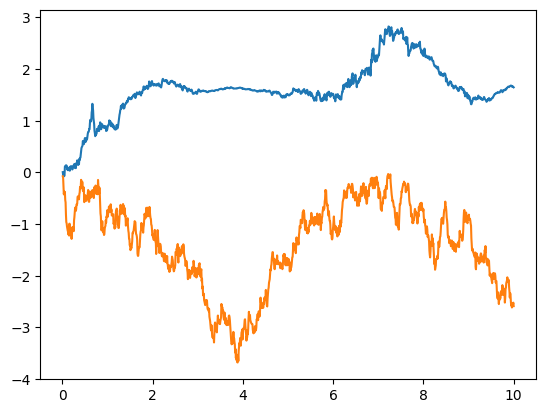

In [2]:
bm_key = jr.key(8)
terms_sabr = get_terms(sabr_sde.get_bm(bm_key, SpaceTimeLevyArea, 2**-8))
sol = diffeqsolve(terms_sabr, SPaRK(), t0, t1, 2**-7, y0, saveat=SaveAt(steps=True))
plot_sol_general(sol)

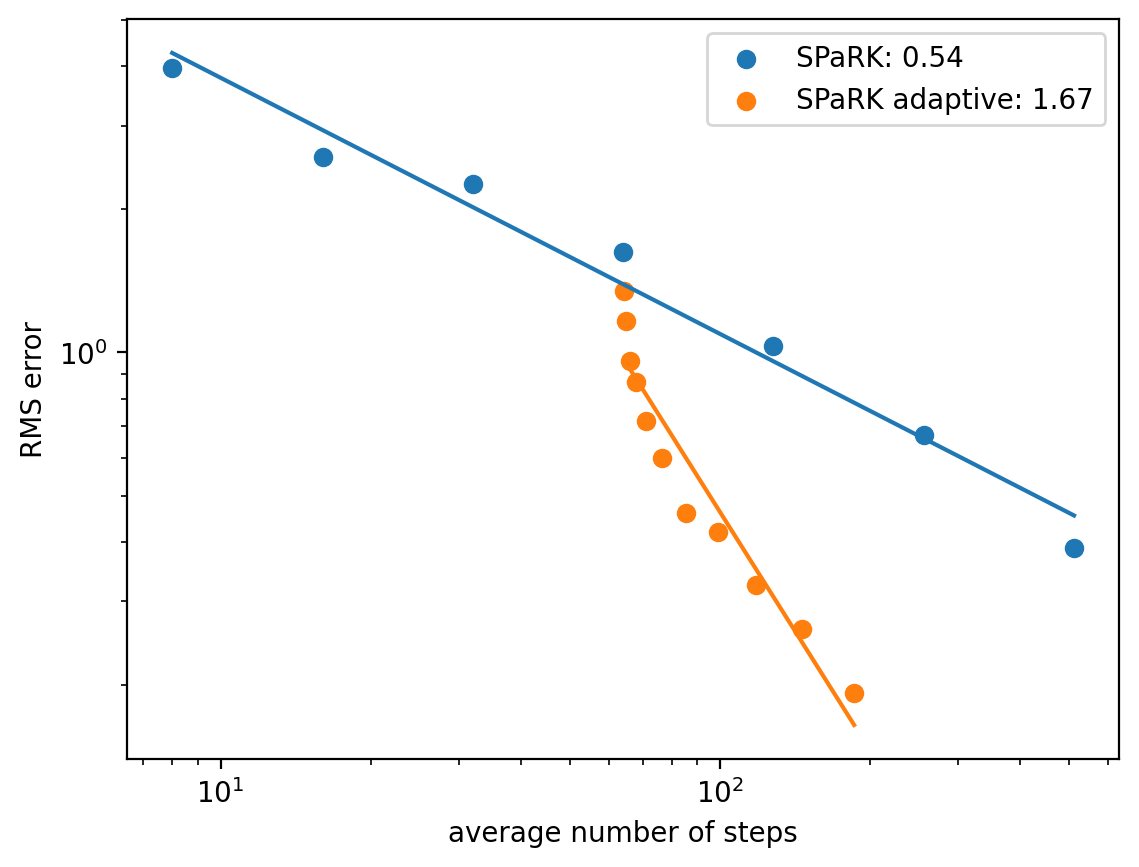

In [3]:
num_samples = 1000
key = jr.key(6)
keys = jr.split(key, num_samples)

sabr_const = constant_step_strong_order(keys, sabr_sde, SPaRK(), (3, 9))


def sabr_strong_order(keys, sde, solver, levels):
    save_ts = jnp.linspace(sde.t0, sde.t1, 65)
    _saveat = SaveAt(ts=save_ts)
    bm_tol = 2**-10

    def get_sabr_controller(level: int):
        return None, SABRController(
            ctol=2**-level, dtmin=2**-9, dtmax=1.0, step_ts=save_ts
        )

    return simple_sde_order(
        keys, sde, solver, solver, levels, get_sabr_controller, _saveat, bm_tol
    )


sabr_adaptive = sabr_strong_order(keys, sabr_sde, SPaRK(), (-8, 2))

draw_order_multiple([sabr_const, sabr_adaptive], ["SPaRK", "SPaRK adaptive"])